In [39]:
import pandas as pd
import os

# Mapping for `run` to `recursive_depth`
RUN_MAPPING = {
    "no_recursion": 0,
    "depth_1": 1,
    "depth_2": 2
}

# Optimization levels corresponding to file names
OPTIMIZATION_LEVELS = {
    "tests_none.csv": "none",
    "tests_speed.csv": "speed",
    "tests_size.csv": "size",
    "tests_autotune.csv": "autotune"
}

def clean_and_load_data(file_name):
    # Determine optimization level from file name
    optimization_level = OPTIMIZATION_LEVELS[os.path.basename(file_name)]

    # Load the data
    df = pd.read_csv(file_name)

    # Map `run` to `recursive_depth`
    df["recursive_depth"] = df["run"].map(RUN_MAPPING)

    # Add the optimization level column
    df["optimization_level"] = optimization_level

    # Clean and rename columns
    df = df.rename(columns={
        "benchmark": "test_name",
        "baseline": "baseline_size",
        "best": "optimum_size",
        "results": "additional_data"
    })

    df["optimum_inlining"] = df["optimum_size"].str.extract(r"(\([^)]*\))")

    # Extract the last numerical values from `baseline_size` and `optimum_size`
    df["baseline_size"] = df["baseline_size"].str.extract(r"(\d+)$").astype(int)
    df["optimum_size"] = df["optimum_size"].str.extract(r"(\d+)$").astype(int)


    # Extract optimum inlining from `best` column

    # Keep only the desired columns
    df = df[[
        "test_name",
        "recursive_depth",
        "optimization_level",
        "baseline_size",
        "optimum_size",
        "optimum_inlining",
        "additional_data"
    ]]

    return df

# List of files to process
files = ["tests_none.csv", "tests_speed.csv", "tests_size.csv", "tests_autotune.csv"]

# Process each file and concatenate the results
dataframes = [clean_and_load_data(file) for file in files]
final_table = pd.concat(dataframes, ignore_index=True)

# Save to a new CSV for further analysis
final_table.to_csv("cleaned_data.csv", index=False)

print("Data cleaning complete. The cleaned data is saved to 'cleaned_data.csv'.")

#show the first 5 rows of the cleaned data
table = final_table
# print where test is "bitwise-ops"
print(table[table["test_name"] == "bitwise-ops"])

Data cleaning complete. The cleaned data is saved to 'cleaned_data.csv'.
       test_name  recursive_depth optimization_level  baseline_size  \
84   bitwise-ops                0               none           3566   
85   bitwise-ops                1               none           3566   
86   bitwise-ops                2               none           3566   
261  bitwise-ops                0              speed           3568   
262  bitwise-ops                1              speed           3568   
263  bitwise-ops                2              speed           3568   
438  bitwise-ops                0               size           3568   
439  bitwise-ops                1               size           3568   
440  bitwise-ops                2               size           3568   
569  bitwise-ops                0           autotune           3568   
627  bitwise-ops                1           autotune           3568   
686  bitwise-ops                2           autotune           3568   

   

In [40]:
# Assume the table has already been loaded into the variable "table"
# Filter the data for recursive depth 0
filtered_table = table[table['recursive_depth'] == 0]

# Group by optimization level and calculate statistics for the baseline_size column
grouped_stats = filtered_table.groupby('optimization_level')['baseline_size']

grouped_stats.describe()

,count,mean,std,min,25%,50%,75%,max
optimization_level,,,,,,,,
autotune,59.0,3454.864407,348.734335,3070.0,3210.0,3306.0,3592.5,4612.0
none,59.0,3420.745763,590.980763,0.0,3212.5,3335.0,3590.5,4879.0
size,59.0,3454.864407,348.734335,3070.0,3210.0,3306.0,3592.5,4612.0
speed,59.0,3454.864407,348.734335,3070.0,3210.0,3306.0,3592.5,4612.0


In [41]:
# Assume the table has already been loaded into the variable "table"
# Filter the data for optimization level "speed"
filtered_table = table[table['optimization_level'] == 'speed']

# Group by recursive depth and calculate statistics for the baseline_size column
grouped_stats = filtered_table.groupby('recursive_depth')['baseline_size']

grouped_stats.describe()

,count,mean,std,min,25%,50%,75%,max
recursive_depth,,,,,,,,
0,59.0,3454.864407,348.734335,3070.0,3210.0,3306.0,3592.5,4612.0
1,59.0,3454.864407,348.734335,3070.0,3210.0,3306.0,3592.5,4612.0
2,59.0,3454.864407,348.734335,3070.0,3210.0,3306.0,3592.5,4612.0


/tmp/ipykernel_4912/280297800.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_table['percentage_reduction'] = ((filtered_table['baseline_size'] - filtered_table['optimum_size']) / filtered_table['baseline_size']) * 100


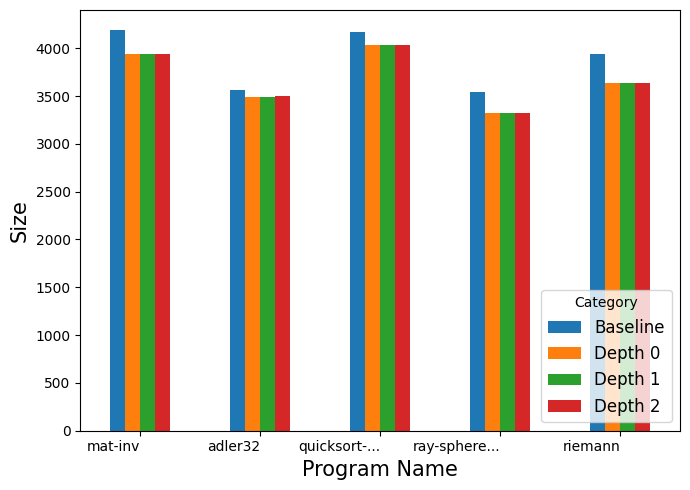

In [97]:
import matplotlib.pyplot as plt
import pandas as pd

# Assume the table has already been loaded into the variable "table"
# Filter the data for optimization level "speed"
filtered_table = table[table['optimization_level'] == 'speed']

# Find the 5 programs with the largest percentage reduction in code size
# Calculate the percentage reduction for each row
filtered_table['percentage_reduction'] = ((filtered_table['baseline_size'] - filtered_table['optimum_size']) / filtered_table['baseline_size']) * 100

# Find the top 5 programs with the highest percentage reduction at recursive depth 0
baseline_depth_0 = filtered_table[filtered_table['recursive_depth'] == 0]
top_programs = baseline_depth_0.nlargest(5, 'percentage_reduction')['test_name']

# Filter the table for these top programs
filtered_top_programs = filtered_table[filtered_table['test_name'].isin(top_programs)]

# Create a new DataFrame for plotting
plot_data = pd.DataFrame()
plot_data['Baseline'] = baseline_depth_0[baseline_depth_0['test_name'].isin(top_programs)].set_index('test_name')['baseline_size']

# Add optimum sizes for each recursive depth
for depth in [0, 1, 2]:
    depth_data = filtered_top_programs[filtered_top_programs['recursive_depth'] == depth]
    plot_data[f'Depth {depth}'] = depth_data.set_index('test_name')['optimum_size']

# Reorder columns for plotting
plot_data = plot_data[['Baseline', 'Depth 0', 'Depth 1', 'Depth 2']]

# Plot the data with a smaller figure size
fig, ax = plt.subplots(figsize=(7, 5))  # Adjust the figure size (half page size)

# Plot the bar chart
plot_data.plot(kind='bar', ax=ax)

# Title and labels with smaller font sizes to fit the plot
ax.set_xlabel('Program Name', fontsize=15)
ax.set_ylabel('Size', fontsize=15)

# Rotate x-axis labels if necessary
plt.xticks(rotation=0, ha='right')
ax.set_xticklabels([
    label.get_text()[:10] + '...' if len(label.get_text()) > 10 else label.get_text()
    for label in ax.get_xticklabels()
])

# Adjust legend location and font size
ax.legend(title='Category', loc='lower right', fontsize=12)


# Ensure the layout is tight to avoid clipping of text
plt.tight_layout()

# Show the plot
plt.show()

/tmp/ipykernel_4912/2310868426.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_table['percentage_reduction'] = ((filtered_table['baseline_size'] - filtered_table['optimum_size']) / filtered_table['baseline_size']) * 100


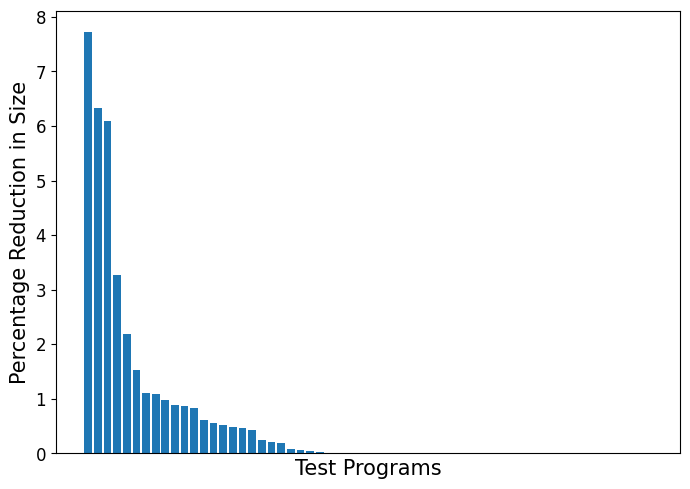

In [84]:
import matplotlib.pyplot as plt
import pandas as pd

# Assume the table has already been loaded into the variable "table"
# Filter the data for optimization level "speed" and recursive depth 0
filtered_table = table[(table['optimization_level'] == 'speed') & (table['recursive_depth'] == 0)]

# Calculate the percentage reduction for each row
filtered_table['percentage_reduction'] = ((filtered_table['baseline_size'] - filtered_table['optimum_size']) / filtered_table['baseline_size']) * 100

# Sort by percentage reduction in descending order
sorted_filtered_table = filtered_table.sort_values(by='percentage_reduction', ascending=False)

# Plot the data
plt.figure(figsize=(10, 6))
plt.bar(sorted_filtered_table['test_name'], sorted_filtered_table['percentage_reduction'])

# Set plot labels and title
plt.title('Percentage Reduction in Code Size for All Tests (Optimization Level: Speed, Depth 0)')
plt.xlabel('Test Program')
plt.ylabel('Percentage Reduction in Size')

# Remove x-axis labels (program names)
plt.xticks([])

# Show the plot
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()


/tmp/ipykernel_4912/4178429413.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_table['percentage_reduction'] = ((filtered_table['baseline_size'] - filtered_table['optimum_size']) / filtered_table['baseline_size']) * 100


                  test_name  baseline_size  optimum_size_speed  \
57                  riemann           3935                3631   
52  ray-sphere-intersection           3543                3319   
1                   mat-inv           4190                3935   
44          quicksort-hoare           4171                4035   
35                  adler32           3566                3488   
23                 sum-bits           3156                3108   
15                   orders           3673                3632   
30             digital-root           3283                3247   
55                   n_root           3269                3237   
9             is-decreasing           3187                3159   

    optimum_size_autotune  percentage_reduction  
57                   3631              7.725540  
52                   3319              6.322326  
1                    3935              6.085919  
44                   4035              3.260609  
35                   34

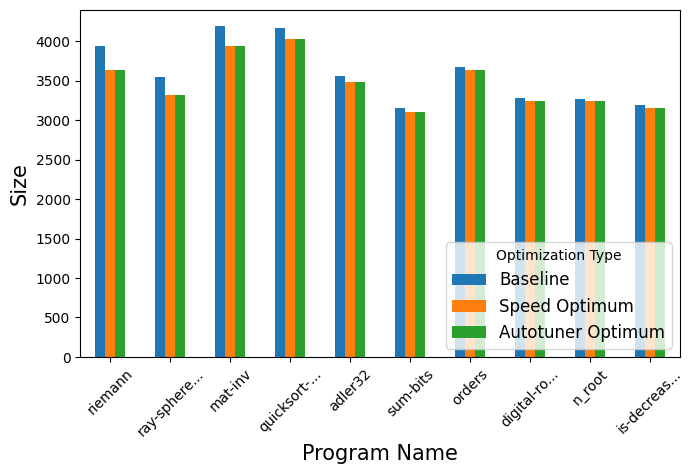

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assume the table has already been loaded into the variable "table"
# Filter the data for recursive depth 0
filtered_table = table[table['recursive_depth'] == 0]

# Calculate the percentage reduction for each row for both speed and autotune
filtered_table['percentage_reduction'] = ((filtered_table['baseline_size'] - filtered_table['optimum_size']) / filtered_table['baseline_size']) * 100

# Filter data for optimization levels 'speed' and 'autotune'
filtered_speed = filtered_table[filtered_table['optimization_level'] == 'speed']
filtered_autotune = filtered_table[filtered_table['optimization_level'] == 'autotune']

# Merge the speed and autotune data on 'test_name' to get both optimum sizes in one DataFrame
merged_data = pd.merge(filtered_speed[['test_name', 'baseline_size', 'optimum_size']],
                       filtered_autotune[['test_name', 'optimum_size']],
                       on='test_name', suffixes=('_speed', '_autotune'))

# Calculate the percentage reduction for both optimization levels
merged_data['percentage_reduction'] = ((merged_data['baseline_size'] - merged_data['optimum_size_speed']) / merged_data['baseline_size']) * 100

# Select the top 10 programs with the largest percentage reduction
top_programs = merged_data.nlargest(10, 'percentage_reduction')

# Create a new DataFrame for plotting
plot_data = pd.DataFrame()
plot_data['Baseline'] = top_programs.set_index('test_name')['baseline_size']
plot_data['Speed Optimum'] = top_programs.set_index('test_name')['optimum_size_speed']
plot_data['Autotuner Optimum'] = top_programs.set_index('test_name')['optimum_size_autotune']

print(top_programs)
# Plot the data
ax = plot_data.plot(kind='bar', figsize=(7, 5))

# Set the plot title and labels
ax.set_xlabel('Program Name', fontsize=15)
ax.set_ylabel('Size', fontsize=15)
ax.set_xticklabels([
    label.get_text()[:10] + '...' if len(label.get_text()) > 10 else label.get_text()
    for label in ax.get_xticklabels()
])
# Move the legend outside the plot to avoid overlap
ax.legend(title='Optimization Type', loc='lower right', fontsize=12)

# Adjust layout to prevent clipping of content
plt.tight_layout()
plt.xticks(rotation=45)


# Show the plot
plt.show()


In [63]:
import pandas as pd

# Create a dictionary to represent the data for the three new tests
data = {
    'test_name': ['conjugate-gradient', 'matops', 'nbody'],
    'recursive_depth': [0, 0, 0],
    'optimization_level': ['autotune', 'autotune', 'autotune'],
    'baseline_size': [5012, 7019, 5648],
    'optimum_size': [5012, 6869, 5616],
    'optimum_inlining': [
        '()', 
        "(('fsqrt', 'fabs'), ('mat_det', 'mod'), ('power_iteration', 'fabs'))", 
        "('fsqrt', 'fabs')"
    ],
    'additional_data': [
        '() 5012, () 5012, () 5012,() 5012, () 5012, () 5012, () 5012', 
        "() 7019, (('fsqrt', 'fabs'), ('mat_det', 'mod'), ('power_iteration', 'fabs')) 6869, (('fsqrt', 'fabs'), ('mat_det', 'mod'), ('power_iteration', 'fabs')) 6869, (('fsqrt', 'fabs'), ('mat_det', 'mod'), ('power_iteration', 'fabs')) 6869, (('fsqrt', 'fabs'), ('mat_det', 'mod'), ('power_iteration', 'fabs')) 6869, (('fsqrt', 'fabs'), ('mat_det', 'mod'), ('power_iteration', 'fabs')) 6869, (('fsqrt', 'fabs'), ('mat_det', 'mod'), ('power_iteration', 'fabs')) 6869", 
        "() 5648, (('fsqrt', 'fabs'),) 5616, (('fsqrt', 'fabs'),) 5616, (('fsqrt', 'fabs'),) 5616, (('fsqrt', 'fabs'),) 5616, (('fsqrt', 'fabs'),) 5616, (('fsqrt', 'fabs'),) 5616"
    ]
}

# Create the DataFrame
df_new_tests = pd.DataFrame(data)

# Display the new DataFrame
print(df_new_tests)


            test_name  recursive_depth optimization_level  baseline_size  \
0  conjugate-gradient                0           autotune           5012   
1              matops                0           autotune           7019   
2               nbody                0           autotune           5648   

   optimum_size                                   optimum_inlining  \
0          5012                                                 ()   
1          6869  (('fsqrt', 'fabs'), ('mat_det', 'mod'), ('powe...   
2          5616                                  ('fsqrt', 'fabs')   

                                     additional_data  
0  () 5012, () 5012, () 5012,() 5012, () 5012, ()...  
1  () 7019, (('fsqrt', 'fabs'), ('mat_det', 'mod'...  
2  () 5648, (('fsqrt', 'fabs'),) 5616, (('fsqrt',...  


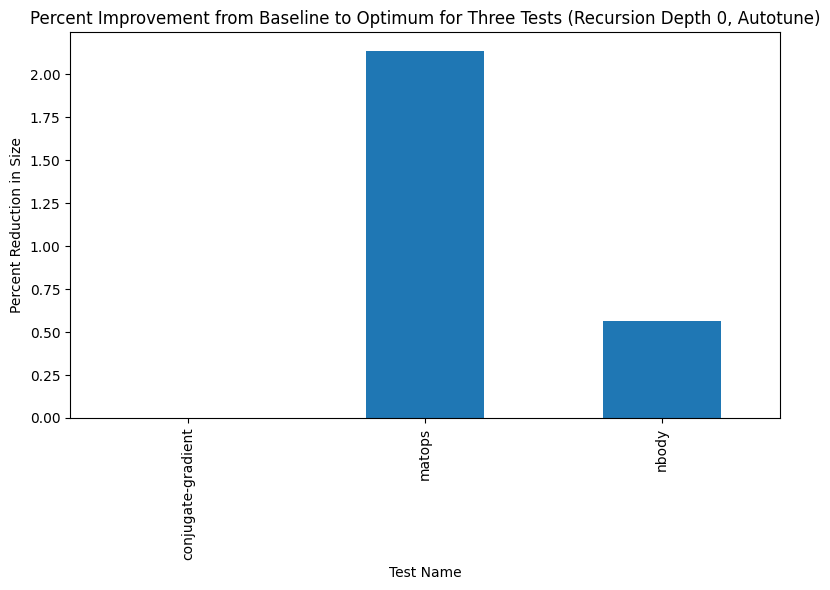

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a dictionary to represent the data for the three new tests
data = {
    'test_name': ['conjugate-gradient', 'matops', 'nbody'],
    'baseline_size': [5012, 7019, 5648],
    'optimum_size': [5012, 6869, 5616]
}

# Create the DataFrame
df_new_tests = pd.DataFrame(data)

# Calculate percent improvement for each test
df_new_tests['percent_improvement'] = ((df_new_tests['baseline_size'] - df_new_tests['optimum_size']) / df_new_tests['baseline_size']) * 100

# Plot the percent improvement
ax = df_new_tests.set_index('test_name')['percent_improvement'].plot(kind='bar', figsize=(7, 5))

# Set plot title and labels
ax.set_xlabel('Test Name', fontsize=15)
ax.set_ylabel('Percent Reduction in Size', fontsize=15)

plt.xticks(rotation=0, fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()
